In [2]:
import torch
import torch.nn as nn

class MC_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.column1 = nn.Sequential(
            nn.Conv2d(3, 8, 9, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 7, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 7, padding='same'),
            nn.ReLU(),
            nn.Conv2d(32, 16, 7, padding='same'),
            nn.ReLU(),
            nn.Conv2d(16, 8, 7, padding='same'),
            nn.ReLU(),
        )

        self.column2 = nn.Sequential(
            nn.Conv2d(3, 10, 7,padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 20, 5,padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, 5,padding='same'),
            nn.ReLU(),
            nn.Conv2d(40, 20, 5,padding='same'),
            nn.ReLU(),
            nn.Conv2d(20, 10, 5,padding='same'),
            nn.ReLU(),
        )

        self.column3 = nn.Sequential(
            nn.Conv2d(3, 12, 5, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(12, 24, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(48, 24, 3, padding='same'),
            nn.ReLU(),
            nn.Conv2d(24, 12, 3, padding='same'),
            nn.ReLU(),
        )


        self.fusion_layer = nn.Sequential(
            nn.Conv2d(30, 1, 1, padding=0),
            #nn.ReLU()
        )


    def forward(self,img_tensor):
        x1 = self.column1(img_tensor)
        x2 = self.column2(img_tensor)
        x3 = self.column3(img_tensor)
        x = torch.cat((x1, x2, x3),1)
        x = self.fusion_layer(x)
        return x

Device: cpu
✅ Model loaded!
✅ Count: 90.8


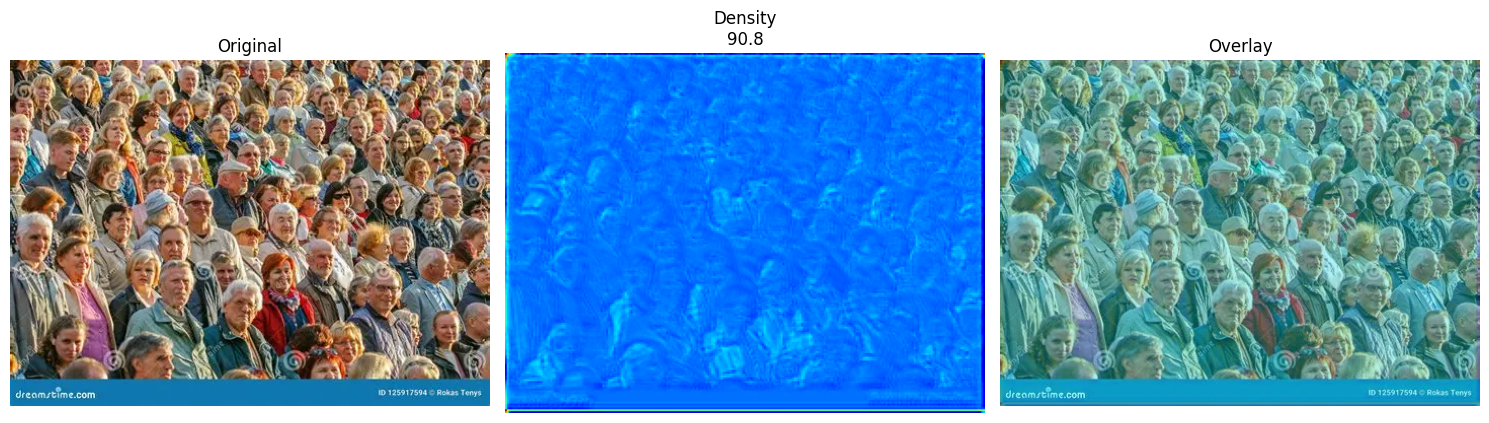

In [4]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'  # Your device
print("Device:", device)

# BEST: Load state_dict (standard PyTorch)
model = MC_CNN().to(device)
model.load_state_dict(torch.load("./crowd_counting.pth", map_location=device), strict=False)
model.eval()
print(" Model loaded!")

def predict_density(img_path):
    bgr = cv2.imread(img_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (1024, 768))
    img = resized.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    tensor = torch.from_numpy(img).unsqueeze(0).to(device)

    with torch.no_grad():
        dmap = model(tensor)

    dmap_np = dmap.squeeze().cpu().numpy()
    count = dmap_np.sum()
    print(f" Count: {count:.1f}")
    return bgr, dmap_np, count

# TEST
img_path = r"C:\Users\lekha\Downloads\OIP.webp"
result = predict_density(img_path)

if result:
    orig_bgr, dmap, count = result
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(orig_rgb); plt.title("Original"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(dmap, cmap='jet'); plt.title(f"Density\n{count:.1f}"); plt.axis('off')

    heatmap = cv2.applyColorMap((dmap/np.max(dmap+1e-6)*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.resize(heatmap, (orig_bgr.shape[1], orig_bgr.shape[0]))
    overlay = cv2.addWeighted(orig_bgr, 0.7, heatmap, 0.3, 0)
    plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Overlay"); plt.axis('off')
    plt.tight_layout(); plt.show()


In [7]:
# CELL 2: LOAD MODEL (RUN ONCE PER SESSION)
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'  # or 'cuda:0' if GPU
model = MC_CNN().to(device)
model.load_state_dict(torch.load("./crowd_counting.pth", map_location=device), strict=False)
model.eval()
print("🚀 Model LOADED - Ready for inference!")

def predict_density(img_path):
    """Predict crowd density - JUST CHANGE img_path"""
    bgr = cv2.imread(img_path)
    if bgr is None:
        print(f"❌ Image not found: {img_path}")
        return None

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (1024, 768))  # YOUR TRAINING SIZE
    img = resized.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    tensor = torch.from_numpy(img).unsqueeze(0).to(device)

    with torch.no_grad():
        dmap = model(tensor)

    dmap_np = dmap.squeeze().cpu().numpy()
    count = float(dmap_np.sum())

    print(f"✅ Crowd count: {count:.1f}")
    return bgr, dmap_np, count

print("✅ SETUP COMPLETE!")


🚀 Model LOADED - Ready for inference!
✅ SETUP COMPLETE!


✅ Crowd count: 90.8


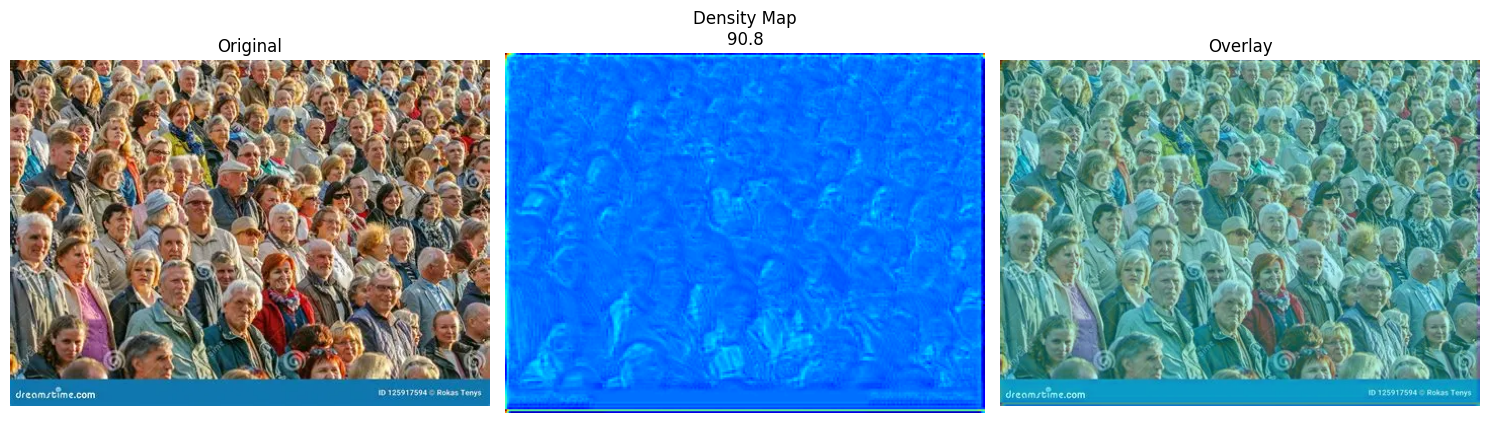

In [8]:
# CELL 3: ONE-LINE PREDICTION (CHANGE ONLY PATH)
img_path = r"C:\Users\lekha\Downloads\OIP.webp"  # ← JUST CHANGE THIS!

result = predict_density(img_path)

if result:
    orig_bgr, dmap_np, count = result
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(orig_rgb); plt.title("Original"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(dmap_np, cmap='jet'); plt.title(f"Density Map\n{count:.1f}"); plt.axis('off')

    # Overlay
    heatmap = cv2.applyColorMap((dmap_np/np.max(dmap_np+1e-6)*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.resize(heatmap, (orig_bgr.shape[1], orig_bgr.shape[0]))
    overlay = cv2.addWeighted(orig_bgr, 0.7, heatmap, 0.3, 0)
    plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.title("Overlay"); plt.axis('off')

    plt.tight_layout()
    plt.show()
